#  Exploring Clustering Techniques with Python Assignment Day 38
by Rizky Febri Ibra Habibie

# 1. Data Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Load data
df = pd.read_csv('flight.csv')
df.head()

,MEMBER_NO,FFP_DATE,FIRST_FLIGHT_DATE,GENDER,FFP_TIER,WORK_CITY,WORK_PROVINCE,WORK_COUNTRY,AGE,LOAD_TIME,...,SUM_YR_2,SEG_KM_SUM,LAST_FLIGHT_DATE,LAST_TO_END,AVG_INTERVAL,MAX_INTERVAL,EXCHANGE_COUNT,avg_discount,Points_Sum,Point_NotFlight
0,54993,11/2/2006,12/24/2008,Male,6,.,beijing,CN,31.0,3/31/2014,...,234188.0,580717,3/31/2014,1,3.483254,18,34,0.961639,619760,50
1,28065,2/19/2007,8/3/2007,Male,6,NaN,beijing,CN,42.0,3/31/2014,...,167434.0,293678,3/25/2014,7,5.194245,17,29,1.252314,415768,33
2,55106,2/1/2007,8/30/2007,Male,6,.,beijing,CN,40.0,3/31/2014,...,164982.0,283712,3/21/2014,11,5.298507,18,20,1.254676,406361,26
3,21189,8/22/2008,8/23/2008,Male,5,Los Angeles,CA,US,64.0,3/31/2014,...,125500.0,281336,12/26/2013,97,27.863636,73,11,1.090870,372204,12
4,39546,4/10/2009,4/15/2009,Male,6,guiyang,guizhou,CN,48.0,3/31/2014,...,130702.0,309928,3/27/2014,5,4.788079,47,27,0.970658,338813,39


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62988 entries, 0 to 62987
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   MEMBER_NO          62988 non-null  int64  
 1   FFP_DATE           62988 non-null  object 
 2   FIRST_FLIGHT_DATE  62988 non-null  object 
 3   GENDER             62985 non-null  object 
 4   FFP_TIER           62988 non-null  int64  
 5   WORK_CITY          60719 non-null  object 
 6   WORK_PROVINCE      59740 non-null  object 
 7   WORK_COUNTRY       62962 non-null  object 
 8   AGE                62568 non-null  float64
 9   LOAD_TIME          62988 non-null  object 
 10  FLIGHT_COUNT       62988 non-null  int64  
 11  BP_SUM             62988 non-null  int64  
 12  SUM_YR_1           62437 non-null  float64
 13  SUM_YR_2           62850 non-null  float64
 14  SEG_KM_SUM         62988 non-null  int64  
 15  LAST_FLIGHT_DATE   62988 non-null  object 
 16  LAST_TO_END        629

In [3]:
df.isnull().sum()

MEMBER_NO               0
FFP_DATE                0
FIRST_FLIGHT_DATE       0
GENDER                  3
FFP_TIER                0
WORK_CITY            2269
WORK_PROVINCE        3248
WORK_COUNTRY           26
AGE                   420
LOAD_TIME               0
FLIGHT_COUNT            0
BP_SUM                  0
SUM_YR_1              551
SUM_YR_2              138
SEG_KM_SUM              0
LAST_FLIGHT_DATE        0
LAST_TO_END             0
AVG_INTERVAL            0
MAX_INTERVAL            0
EXCHANGE_COUNT          0
avg_discount            0
Points_Sum              0
Point_NotFlight         0
dtype: int64

In [4]:
df.describe()

,MEMBER_NO,FFP_TIER,AGE,FLIGHT_COUNT,BP_SUM,SUM_YR_1,SUM_YR_2,SEG_KM_SUM,LAST_TO_END,AVG_INTERVAL,MAX_INTERVAL,EXCHANGE_COUNT,avg_discount,Points_Sum,Point_NotFlight
count,62988.000000,62988.000000,62568.000000,62988.000000,62988.000000,62437.000000,62850.000000,62988.000000,62988.000000,62988.000000,62988.000000,62988.000000,62988.000000,62988.0000,62988.000000
mean,31494.500000,4.102162,42.476346,11.839414,10925.081254,5355.376064,5604.026014,17123.878691,176.120102,67.749788,166.033895,0.319775,0.721558,12545.7771,2.728155
std,18183.213715,0.373856,9.885915,14.049471,16339.486151,8109.450147,8703.364247,20960.844623,183.822223,77.517866,123.397180,1.136004,0.185427,20507.8167,7.364164
min,1.000000,4.000000,6.000000,2.000000,0.000000,0.000000,0.000000,368.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000
25%,15747.750000,4.000000,35.000000,3.000000,2518.000000,1003.000000,780.000000,4747.000000,29.000000,23.370370,79.000000,0.000000,0.611997,2775.0000,0.000000
50%,31494.500000,4.000000,41.000000,7.000000,5700.000000,2800.000000,2773.000000,9994.000000,108.000000,44.666667,143.000000,0.000000,0.711856,6328.5000,0.000000
75%,47241.250000,4.000000,48.000000,15.000000,12831.000000,6574.000000,6845.750000,21271.250000,268.000000,82.000000,228.000000,0.000000,0.809476,14302.5000,1.000000
max,62988.000000,6.000000,110.000000,213.000000,505308.000000,239560.000000,234188.000000,580717.000000,731.000000,728.000000,728.000000,46.000000,1.500000,985572.0000,140.000000


In [5]:
# Drop kolom identitas dan non-numeric
drop_cols = ['MEMBER_NO', 'FFP_DATE', 'FIRST_FLIGHT_DATE', 'GENDER',
             'WORK_CITY', 'WORK_PROVINCE', 'WORK_COUNTRY',
             'LOAD_TIME', 'LAST_FLIGHT_DATE']
df_clean = df.drop(columns=drop_cols)

In [6]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62988 entries, 0 to 62987
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   FFP_TIER         62988 non-null  int64  
 1   AGE              62568 non-null  float64
 2   FLIGHT_COUNT     62988 non-null  int64  
 3   BP_SUM           62988 non-null  int64  
 4   SUM_YR_1         62437 non-null  float64
 5   SUM_YR_2         62850 non-null  float64
 6   SEG_KM_SUM       62988 non-null  int64  
 7   LAST_TO_END      62988 non-null  int64  
 8   AVG_INTERVAL     62988 non-null  float64
 9   MAX_INTERVAL     62988 non-null  int64  
 10  EXCHANGE_COUNT   62988 non-null  int64  
 11  avg_discount     62988 non-null  float64
 12  Points_Sum       62988 non-null  int64  
 13  Point_NotFlight  62988 non-null  int64  
dtypes: float64(5), int64(9)
memory usage: 6.7 MB


In [7]:
df_clean.isnull().sum()

FFP_TIER             0
AGE                420
FLIGHT_COUNT         0
BP_SUM               0
SUM_YR_1           551
SUM_YR_2           138
SEG_KM_SUM           0
LAST_TO_END          0
AVG_INTERVAL         0
MAX_INTERVAL         0
EXCHANGE_COUNT       0
avg_discount         0
Points_Sum           0
Point_NotFlight      0
dtype: int64

Missing value <10% maka kita lakukan penggunaan median

In [8]:
df_clean = df_clean.fillna(df_clean.median(numeric_only=True))

In [9]:
# Simpan kolom untuk clustering
features = df_clean.columns.tolist()

In [10]:
# Scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_clean)

scaled_df = pd.DataFrame(scaled_data, columns=features)
scaled_df.head()

,FFP_TIER,AGE,FLIGHT_COUNT,BP_SUM,SUM_YR_1,SUM_YR_2,SEG_KM_SUM,LAST_TO_END,AVG_INTERVAL,MAX_INTERVAL,EXCHANGE_COUNT,avg_discount,Points_Sum,Point_NotFlight
0,5.076427,-1.163692,14.104600,30.257184,28.998020,26.290557,26.888115,-0.952668,-0.829061,-1.199663,29.648208,1.294761,29.609151,6.419225
1,5.076427,-0.047343,9.122166,21.515836,20.569878,18.613063,13.193949,-0.920027,-0.806989,-1.207767,25.246781,2.862377,19.662036,4.110730
2,5.076427,-0.250316,8.766278,20.822969,19.596167,18.331054,12.718487,-0.898267,-0.805644,-1.199663,17.324213,2.875110,19.203329,3.160173
3,2.401579,2.185353,0.794384,19.975629,13.744243,13.790160,12.605132,-0.430420,-0.514545,-0.753945,9.401645,1.991703,17.537756,1.259059
4,5.076427,0.561574,9.976297,16.091143,14.760666,14.388451,13.969210,-0.930907,-0.812228,-0.964648,23.486211,1.343400,15.909534,4.925493


# 2. Exploratory Data Analysis (EDA)

In [11]:
# Correlation matrix
correlation_matrix = df_clean.corr()

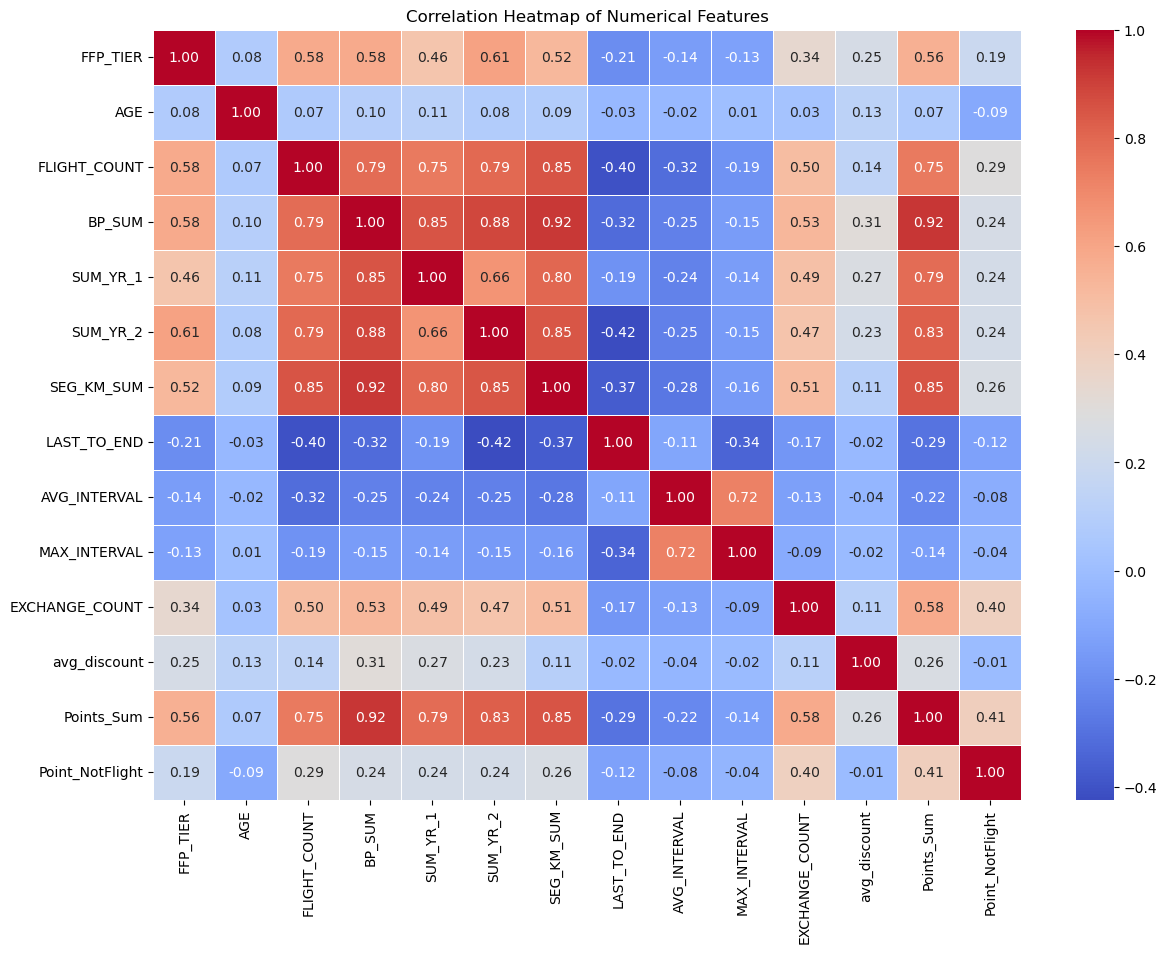

In [12]:
# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

- SUM_YR_1, SUM_YR_2, SEG_KM_SUM, FLIGHT_COUNT, BP_SUM, dan Points_Sum memiliki korelasi positif yang tinggi satu sama lain — ini menunjukkan bahwa pelanggan yang sering terbang juga cenderung mendapatkan poin lebih banyak.
- avg_discount memiliki korelasi negatif dengan banyak variabel — artinya pelanggan yang sering mendapatkan diskon cenderung memiliki lebih sedikit penerbangan atau poin.

# 3. Clustering dengan K-Means

Untuk menemukan jumlah cluster terbaik, kita akan menggunakan:
- Elbow Method
- Silhouette Score

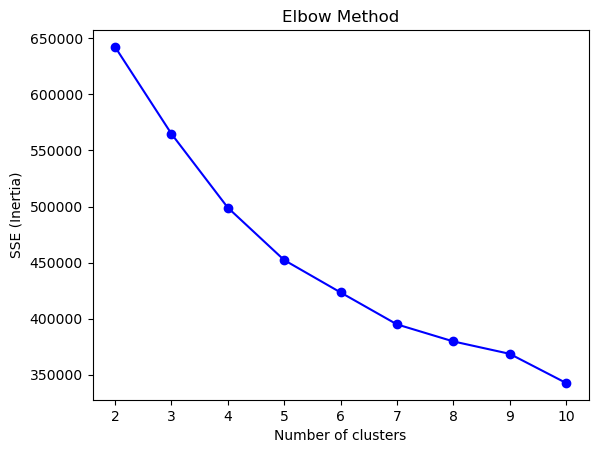

In [13]:
# Elbow Method
sse = []
K = range(2, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_df)
    sse.append(kmeans.inertia_)

plt.plot(K, sse, 'bo-')
plt.xlabel('Number of clusters')
plt.ylabel('SSE (Inertia)')
plt.title('Elbow Method')
plt.show()

In [14]:
# Silhouette Score
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    preds = kmeans.fit_predict(scaled_df)
    score = silhouette_score(scaled_df, preds)
    print(f"Clusters = {k}, Silhouette Score = {score:.4f}")

Clusters = 2, Silhouette Score = 0.5247
Clusters = 3, Silhouette Score = 0.2749
Clusters = 4, Silhouette Score = 0.1741
Clusters = 5, Silhouette Score = 0.1836
Clusters = 6, Silhouette Score = 0.1720
Clusters = 7, Silhouette Score = 0.1845
Clusters = 8, Silhouette Score = 0.1603
Clusters = 9, Silhouette Score = 0.1418
Clusters = 10, Silhouette Score = 0.1624


# 4. Visualisasi Hasil Clustering

In [15]:
# Gunakan k=2 berdasarkan analisis sebelumnya
k_optimal = 2
kmeans = KMeans(n_clusters=k_optimal, random_state=42)
cluster_labels = kmeans.fit_predict(scaled_df)

In [16]:
# Tambahkan hasil cluster ke dataframe
df_clean['Cluster'] = cluster_labels
df_clean.head()

,FFP_TIER,AGE,FLIGHT_COUNT,BP_SUM,SUM_YR_1,SUM_YR_2,SEG_KM_SUM,LAST_TO_END,AVG_INTERVAL,MAX_INTERVAL,EXCHANGE_COUNT,avg_discount,Points_Sum,Point_NotFlight,Cluster
0,6,31.0,210,505308,239560.0,234188.0,580717,1,3.483254,18,34,0.961639,619760,50,1
1,6,42.0,140,362480,171483.0,167434.0,293678,7,5.194245,17,29,1.252314,415768,33,1
2,6,40.0,135,351159,163618.0,164982.0,283712,11,5.298507,18,20,1.254676,406361,26,1
3,5,64.0,23,337314,116350.0,125500.0,281336,97,27.863636,73,11,1.090870,372204,12,1
4,6,48.0,152,273844,124560.0,130702.0,309928,5,4.788079,47,27,0.970658,338813,39,1


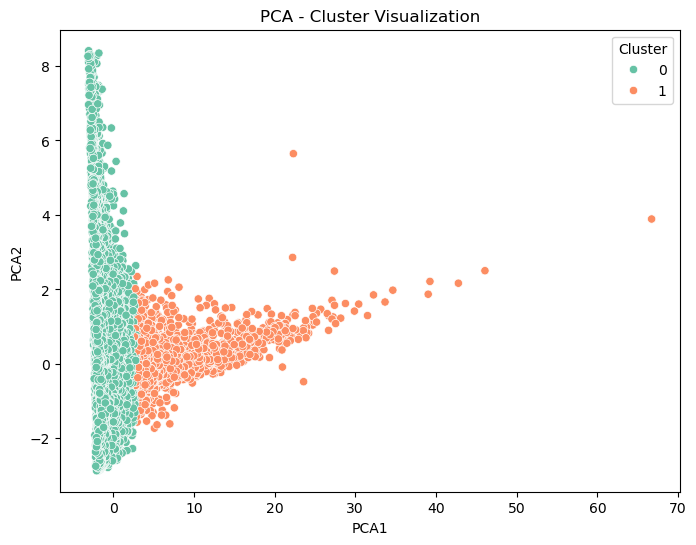

In [17]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_df)

df_clean['PCA1'] = pca_result[:, 0]
df_clean['PCA2'] = pca_result[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_clean, x='PCA1', y='PCA2', hue='Cluster', palette='Set2')
plt.title('PCA - Cluster Visualization')
plt.show()


# 5. Evaluasi Model

In [18]:
silhouette = silhouette_score(scaled_df, cluster_labels)
print(f"Silhouette Score Final Model: {silhouette:.4f}")

Silhouette Score Final Model: 0.5247


Dua metode evaluasi digunakan untuk menentukan jumlah cluster optimal:

- **Silhouette Score** menilai seberapa baik tiap titik berada dalam cluster-nya. Skor terbaik diperoleh saat `k = 2`, yaitu **0.5247**, jauh lebih tinggi dari lainnya.
- **Elbow Method** menganalisis SSE. Terlihat 'elbow' pada `k = 4` atau `k = 5`, di mana penurunan SSE mulai melambat.

Namun, karena Silhouette Score lebih fokus pada kualitas pemisahan cluster, maka **k = 2** dipilih sebagai jumlah cluster optimal.


# 6. Insight dan Rekomendasi

In [23]:
# Tampilkan ringkasan statistik tiap cluster
cluster_summary = df_clean.groupby('Cluster').mean().round(2)
print("Rangkuman Statistik Tiap Cluster:")
print(cluster_summary)

Rangkuman Statistik Tiap Cluster:
         FFP_TIER    AGE  FLIGHT_COUNT    BP_SUM  SUM_YR_1  SUM_YR_2  \
Cluster                                                                
0            4.03  42.25          8.59   7200.99   3682.13   3671.72   
1            4.84  44.62         44.07  47854.95  21704.07  24698.00   

         SEG_KM_SUM  LAST_TO_END  AVG_INTERVAL  MAX_INTERVAL  EXCHANGE_COUNT  \
Cluster                                                                        
0          12315.51       190.71         72.66        172.96            0.15   
1          64805.94        31.48         19.02         97.37            2.02   

         avg_discount  Points_Sum  Point_NotFlight  PCA1  PCA2  
Cluster                                                         
0                0.71     8090.03             2.09 -0.62 -0.00  
1                0.84    56731.08             9.02  6.12  0.01  


### Insight dan Rekomendasi Bisnis

Berdasarkan hasil clustering (k=2), kita dapat mengelompokkan pelanggan menjadi dua tipe utama:

####  Cluster 0 — Pelanggan Pasif
- Jarang terbang (8.6 kali), poin rendah
- Tidak banyak menggunakan penawaran atau menukar poin
- Perlu strategi retensi: promosi diskon, reaktivasi, kampanye khusus

####  Cluster 1 — Pelanggan Loyal dan Aktif
- Sering terbang (44 kali), poin tinggi
- Rajin menukar poin dan berinteraksi
- Perlu strategi loyalitas: benefit eksklusif, prioritas layanan, bundling

Dengan pendekatan berbeda untuk tiap cluster, perusahaan bisa meningkatkan keterlibatan dan nilai pelanggan.
